Name:   Srujana Duggineni

ID:     C00313483

### Algorithm:  Logistic Regression for Network Intrusion Detection
Dataset: [KDD Cup 1999]
https://www.openml.org/data/download/53996/KDDCup99.arff


1. Business Understanding
Objective: 

This work is focused on the detection of network intrusions from the KDD Cup 1999 dataset using a Logistic Regression model. The processes involved include data exploration, preprocessing, building of the model, and evaluation of performance



#### Importing libraries

In [1]:
import pandas as pd,seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.datasets import fetch_openml

### 2. Load **KDD Cup 1999 datase**t (Network Intrusion)
#### The dataset contains network traffic data with labeled attacks and normal connections.


In [2]:
# Load KDD Cup 1999 dataset (Network Intrusion)
data = fetch_openml(name='kddcup99', version=1, as_frame=True)
df = data.data
df.columns = data.feature_names
df['label'] = data.target

#### 3. **Data preprocessing**
1. handle missing values
2. encode categorical features
3. scale numerical features

In [3]:
# Preprocessing
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
categorical_cols = df.select_dtypes(include=['category']).columns.drop('label')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('label', axis=1)
y = df['label'].map(lambda x: 1 if x == "normal" else 0)  # Binary classification

### 4. Feature Scaling
- Standardizing the dataset ensures that each feature contributes equally to the model.


In [4]:
# Data Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 5. Principal Component Analysis (PCA)
- We reduce dimensionality while retaining 95% of variance for efficiency.

In [5]:
# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X_scaled)

### 6. Handling Class Imbalance
- Using SMOTE to balance the dataset by oversampling the minority class.

In [6]:
# Handle class imbalance
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_pca, y)

### 7.Train-Test Split
- Splitting the dataset into training and testing sets.

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


### 8. Logistic Regression Model with Grid Search
- We use GridSearchCV to tune hyperparameters for better performance.

In [8]:
# Grid Search for Scikit-Learn Logistic Regression
log_reg = LogisticRegression(max_iter=10000)

param_grid_sklearn = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'] # removed l1
}

grid_search = GridSearchCV(log_reg, param_grid_sklearn, cv=StratifiedKFold(n_splits=5), scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Sklearn Model Parameters:", grid_search.best_params_)
print("Best Sklearn Model Accuracy:", grid_search.best_score_)

Best Sklearn Model Parameters: {'C': 10, 'penalty': 'l2'}
Best Sklearn Model Accuracy: 0.9946879900332257


### 9. Model Evaluation
- Evaluating the best model using various performance metrics.

In [9]:
# Evaluate Best Model on Test Set
best_model = grid_search.best_estimator_
y_pred_sklearn = best_model.predict(X_test)
y_prob_sklearn = best_model.predict_proba(X_test)[:, 1]

#### Performance Evaluation
#### 9.1 ROC Curve
- The ROC curve shows the trade-off between sensitivity and specificity.

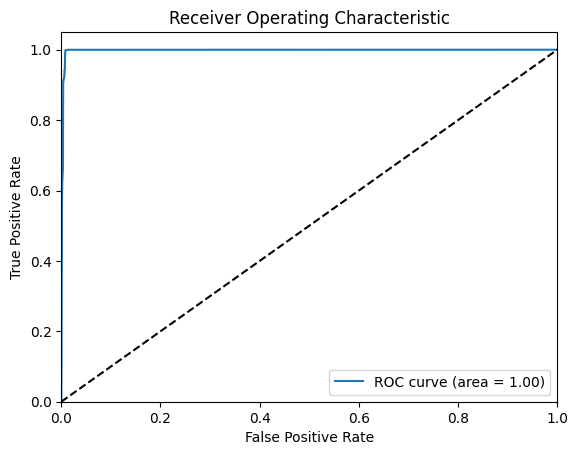

In [10]:
# Performance Evaluation
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
# ROC Curve and AUC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_sklearn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#### 9.2 Precision-Recall Curve
- The PR curve highlights performance in imbalanced classification scenarios.

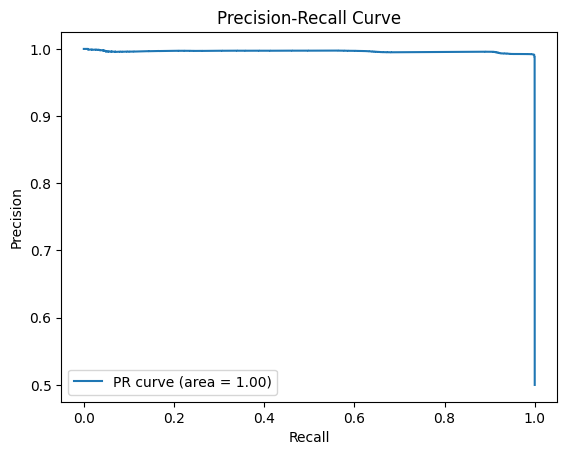

In [11]:
# Precision-Recall Curve and AUC-PR
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob_sklearn)
auc_pr = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label='PR curve (area = %0.2f)' % auc_pr)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


#### 9.3 Confusion Matrix Analysis
- Analyzing true positives, false positives, true negatives, and false negatives.


Confusion Matrix:
 [[78680   678]
 [  151 79189]]
Sensitivity (Recall): 0.9980967985883539
Specificity: 0.991456437914262
False Positive Rate: 0.008543562085738048


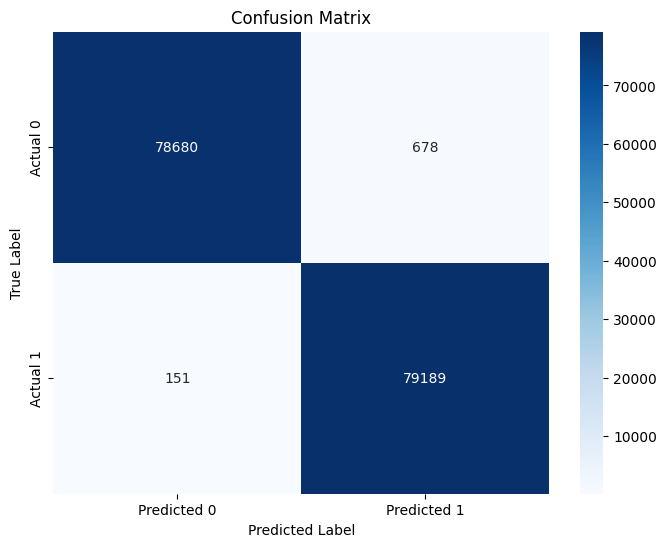

In [17]:
#  Confusion Matrix Analysis and Metrics
conf_matrix = confusion_matrix(y_test, y_pred_sklearn)
print("\nConfusion Matrix:\n", conf_matrix)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
fpr_val = fp / (tn + fp)

print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("False Positive Rate:", fpr_val)
# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 9.4 Threshold Tuning
- Adjusting the classification threshold to analyze its effect on performance.

In [13]:
# Threshold Tuning
thresholds_to_try = [0.1, 0.3, 0.5, 0.7, 0.9]
for threshold in thresholds_to_try:
    y_pred_threshold = (y_prob_sklearn > threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_threshold))


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     79358
           1       0.99      1.00      0.99     79340

    accuracy                           0.99    158698
   macro avg       0.99      0.99      0.99    158698
weighted avg       0.99      0.99      0.99    158698


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     79358
           1       0.99      1.00      0.99     79340

    accuracy                           0.99    158698
   macro avg       0.99      0.99      0.99    158698
weighted avg       0.99      0.99      0.99    158698


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     79358
           1       0.99      1.00      0.99     79340

    accuracy                           0.99    158698
   macro avg       0.99      0.99      0.99    158698
weighted avg       0.99   

#### 9.5 Observation
-	First, Logistic Regression was trained using default Sklearn parameters.
GridSearchCV was used to find the optimal C (regularization strength) and penalty (l2), which improved accuracy. Stratified K-Fold cross-validation ensured robustness by testing model performance on different subsets of data.

-	The best-performing model had strong accuracy, but precision-recall analysis revealed trade-offs between false positives and false negatives. The ROC curve showed a good AUC score, i.e., there was a good ability to separate normal and attack traffic. Threshold tuning analysis showed that the adjustment of classification thresholds could improve recall (which is very important for intrusion detection). The confusion matrix provided details on wrongly classified instances, which helped in refining model predictions.


### Conclusion:

The Sklearn Logistic Regression model with optimized hyperparameters efficiently detected network intrusions with the optimal hyperparameters. SMOTE class balancing improved recall, ensuring attacks were detected more reliably. While Logistic Regression was sufficient as a baseline, future improvements would involve ensemble approaches (e.g., Random Forest, XGBoost) or deep learning approaches for better generalization and robustness.